# Customer Churn Prediction with TabNet

In [ ]:
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from pytorch_tabnet.tab_model import TabNetClassifier

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Training device: {DEVICE}")

PyTorch version: 2.7.1+cu118
Training device: cuda


### Data Setup

In [2]:
# Load the train/validation/test datasets
train_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\train_churn_dataset.csv")
val_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\val_churn_dataset.csv")
test_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\test_churn_dataset.csv")

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (314599, 13)
Validation shape: (67414, 13)
Test shape: (67415, 13)


In [3]:
# Set target column and identify feature columns
TARGET = "Churn"
feature_names = [col for col in train_df.columns if col != TARGET]

# Prepare training, validation, and test datasets for TabNet
X_train = train_df[feature_names].astype(np.float32)
y_train = train_df[TARGET].astype(np.int64)

X_val = val_df[feature_names].astype(np.float32)
y_val = val_df[TARGET].astype(np.int64)

X_test = test_df[feature_names].astype(np.float32)
y_test = test_df[TARGET].astype(np.int64)

### Model Building

In [ ]:
# Build the TabNet model
model = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={"step_size": 10, "gamma": 0.9},
    mask_type="sparsemax",
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.3,
    lambda_sparse=1e-4,
    seed=42,
    verbose=1,
    device_name=DEVICE,
)

In [24]:
# Train the TabNet model
model.fit(
    X_train.values,
    y_train.values,
    eval_set=[(X_val.values, y_val.values)],
    eval_metric=["logloss"],
    max_epochs=20,
    patience=5,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False,
)

epoch 0  | loss: 0.44206 | val_0_logloss: 0.34983 |  0:00:17s
epoch 1  | loss: 0.35787 | val_0_logloss: 0.37555 |  0:00:38s
epoch 2  | loss: 0.3567  | val_0_logloss: 0.48963 |  0:00:56s
epoch 3  | loss: 0.3366  | val_0_logloss: 6.47646 |  0:01:16s
epoch 4  | loss: 0.45752 | val_0_logloss: 0.5976  |  0:01:35s
epoch 5  | loss: 0.40335 | val_0_logloss: 2.20834 |  0:01:55s

Early stopping occurred at epoch 5 with best_epoch = 0 and best_val_0_logloss = 0.34983


### Model Evaluation

In [25]:
# Generate predictions and probabilities for evaluation
test_prob = model.predict_proba(X_test.values)[:, 1]

test_pred = (test_prob >= 0.5).astype(int)

print(f"INITIAL TABNET CLASSIFICATION REPORT:")
print(f"Accuracy: {accuracy_score(y_test.values, test_pred):.4f}")
print(f"Precision: {precision_score(y_test.values, test_pred):.4f}")
print(f"Recall: {recall_score(y_test.values, test_pred):.4f}")
print(f"F1-score: {f1_score(y_test.values, test_pred):.4f}")

INITIAL TABNET CLASSIFICATION REPORT:
Accuracy: 0.8834
Precision: 0.8792
Recall: 0.8890
F1-score: 0.8841


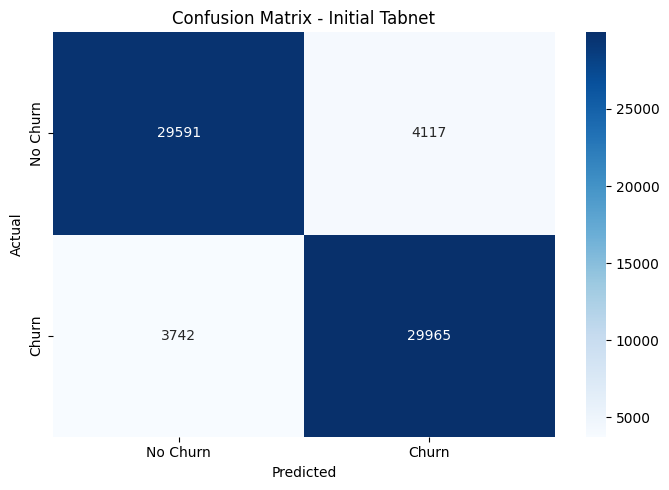

In [26]:
# Full classification report
report = classification_report(
    y_test.values,
    test_pred,
    target_names=["No Churn", "Churn"],
    digits=4,
)

# Confusion matrix visualization
cm = confusion_matrix(y_test.values, test_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
)
plt.title("Confusion Matrix - Initial Tabnet")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

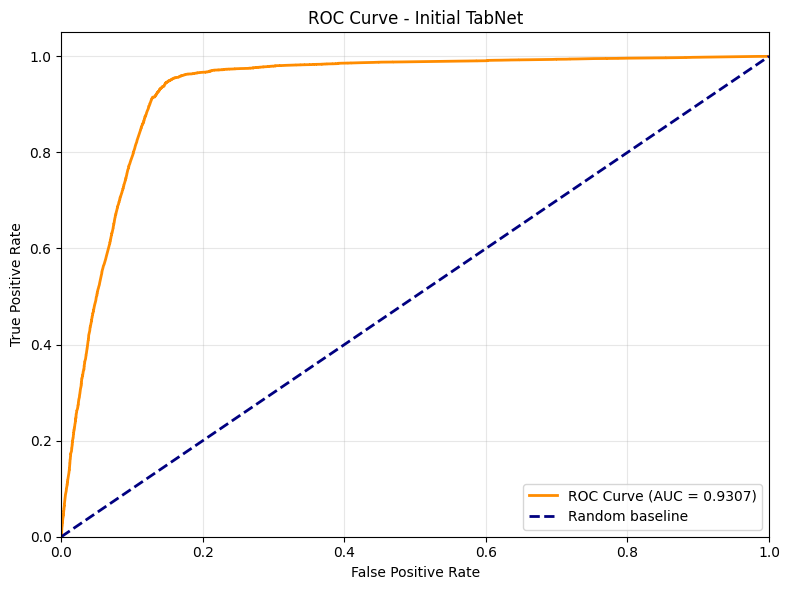

In [29]:
# ROC curve for the test set.
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test.values, test_prob)
roc_auc = roc_auc_score(y_test.values, test_prob)

plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random baseline")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Initial TabNet")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()